<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/RandomForest_improved_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn.csv to customer_churn.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv("customer_churn.csv")

In [ ]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"],errors = "coerce")


In [ ]:
data.drop(["customerID"],inplace = True,axis = 1)

#Visualisation

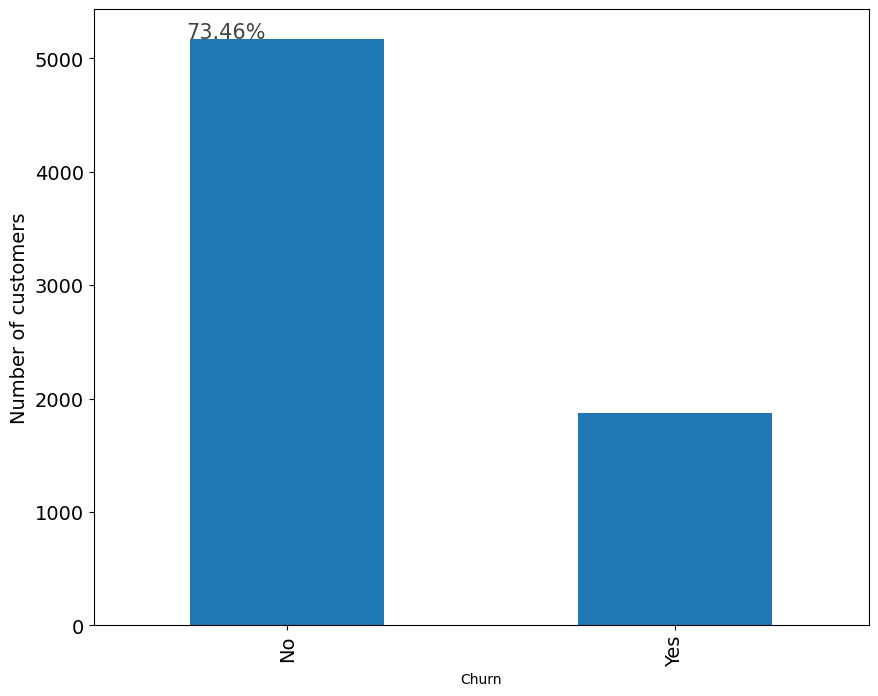

In [ ]:
ax = data["Churn"].value_counts().plot(kind = "bar",figsize = (10,8),fontsize = 14)
ax.set_ylabel("Number of customers",fontsize = 14)

totals = []
for i in ax.patches:
  totals.append(i.get_height())


total = sum(totals)

for i in ax.patches:
  ax.text(i.get_x()- .01,i.get_height() + .5,\
          str(round((i.get_height()/total)*100,2)) + "%",fontsize = 15,
          color = "#444444")
  plt.show()

<Axes: xlabel='MonthlyCharges', ylabel='tenure'>

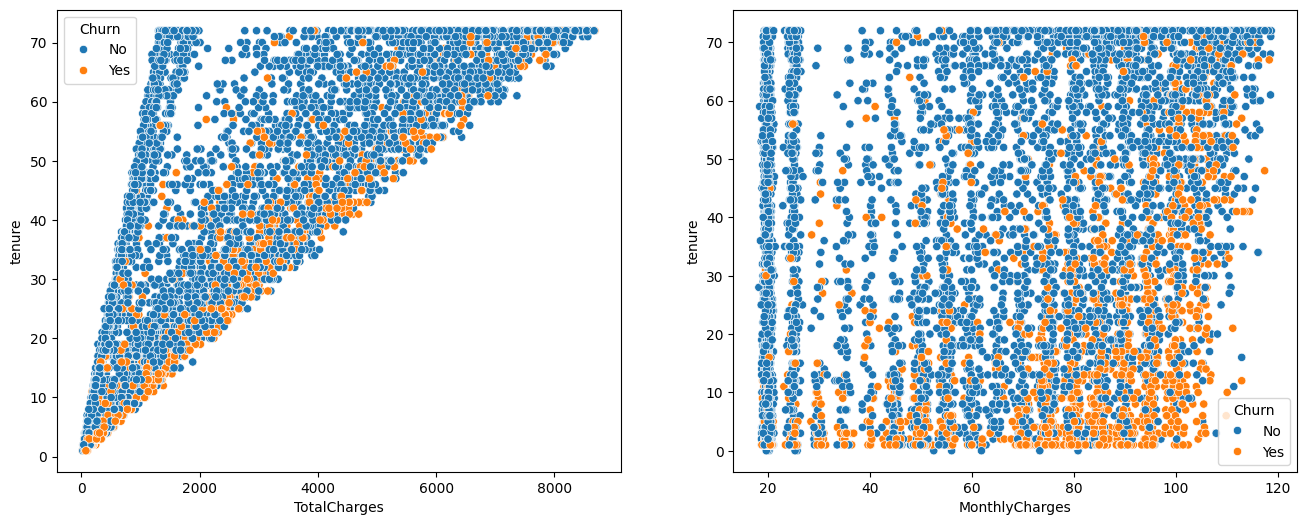

In [ ]:
_,ax = plt.subplots(1,2,figsize= (16,6))
sns.scatterplot(data=data,x = "TotalCharges",y = "tenure",hue = "Churn",ax = ax[0])
sns.scatterplot(data=data,x = "MonthlyCharges",y = "tenure",hue ="Churn",ax = ax[1])

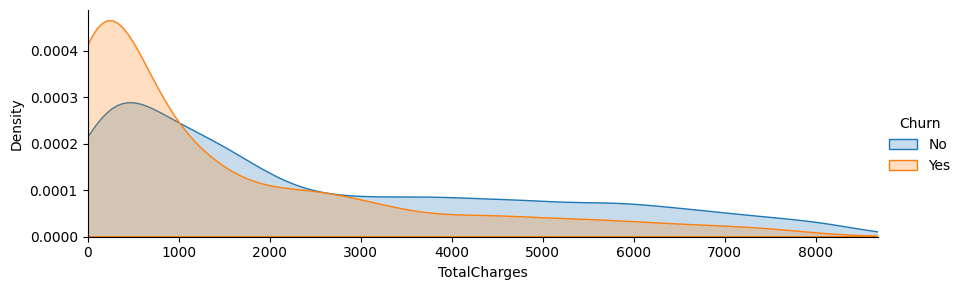

In [ ]:
facet = sns.FacetGrid(data,hue = "Churn",aspect = 3)
facet.map(sns.kdeplot,"TotalCharges",shade = True)
facet.set(xlim = (0,data["TotalCharges"].max()))
facet.add_legend()

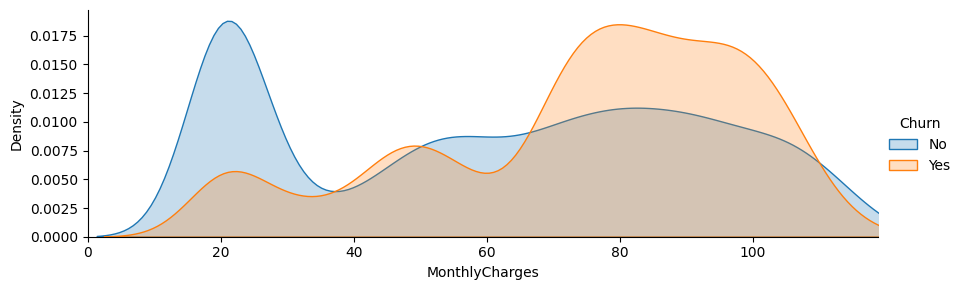

In [ ]:
facet = sns.FacetGrid(data=data,hue = "Churn",aspect = 3)
facet.map(sns.kdeplot,"MonthlyCharges",shade = True)
facet.set(xlim = (0,data["MonthlyCharges"].max()))
facet.add_legend()

In [ ]:
x = data.drop(["Churn"],axis = 1)
y = data["Churn"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 42,stratify = y)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [ ]:
cat_cols = x_train.select_dtypes(include = "object").columns
num_cols = x_train.select_dtypes(exclude = "object").columns

preprocessor = ColumnTransformer(
    transformers = [("cat",OneHotEncoder(handle_unknown = "ignore"),cat_cols)],
    remainder = "passthrough"
)

pipeline= Pipeline(steps = [
    ("preprocessing",preprocessor),
    ("classifier",RandomForestClassifier(random_state = 42))
])

In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
pipeline.fit(x_train,y_train)

pred = pipeline.predict(x_test)
print("Accuracy:",accuracy_score(y_test,pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,pred))
print("\nclassification Report:\n",classification_report(y_test,pred))

Accuracy: 0.7789872219592996

Confusion Matrix:
 [[1383  169]
 [ 298  263]]

classification Report:
               precision    recall  f1-score   support

          No       0.82      0.89      0.86      1552
         Yes       0.61      0.47      0.53       561

    accuracy                           0.78      2113
   macro avg       0.72      0.68      0.69      2113
weighted avg       0.77      0.78      0.77      2113



In [ ]:
rf_model = pipeline.named_steps["classifier"]

ohe = pipeline.named_steps["preprocessing"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(cat_cols)

all_features = list(encoded_features) + list(num_cols)

importance = rf_model.feature_importances_

feature_importance = pd.Series(importance,index = all_features).sort_values(ascending = False)

print(feature_importance.head())

TotalCharges                      0.157385
tenure                            0.141123
MonthlyCharges                    0.135163
Contract_Month-to-month           0.045908
PaymentMethod_Electronic check    0.032950
dtype: float64


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {"classifier__n_estimators":[100,200,300,500],
              "classifier__max_depth":[None,10,20,30],
              "classifier__max_features":["sqrt","log2"],
              "classifier__min_samples_split":[2,5,10],
              "classifier__min_samples_leaf":[1,2,4],
              "classifier__bootstrap":[True,False]}

rf_random = RandomizedSearchCV(estimator = pipeline,
                               param_distributions = param_grid,
                               n_iter = 10,
                               scoring = "f1",
                               cv = 5,
                               verbose = 2,random_state = 42,
                               n_jobs = 1)
rf_random.fit(x_train,y_train)
print("Best params:\n",rf_random.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END classifier__bootstrap=True, classifier__max_depth=30, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=300; total time=   2.5s
[CV] END classifier__bootstrap=True, classifier__max_depth=30, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=300; total time=   1.6s
[CV] END classifier__bootstrap=True, classifier__max_depth=30, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=300; total time=   1.6s
[CV] END classifier__bootstrap=True, classifier__max_depth=30, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=300; total time=   2.4s
[CV] END classifier__bootstrap=True, classifier__max_depth=30, classifier__max_features=sqrt, classifier__m

In [ ]:
best_model = rf_random.best_estimator_
pred_tuned = best_model.predict(x_test)

print("Tuned Accuracy:",accuracy_score(y_test,pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,pred_tuned))
print("\nClassification Report:\n",classification_report(y_test,pred_tuned))

Tuned Accuracy: 0.7789872219592996

Confusion Matrix:
 [[1398  154]
 [ 280  281]]

Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.90      0.87      1552
         Yes       0.65      0.50      0.56       561

    accuracy                           0.79      2113
   macro avg       0.74      0.70      0.71      2113
weighted avg       0.78      0.79      0.79      2113

